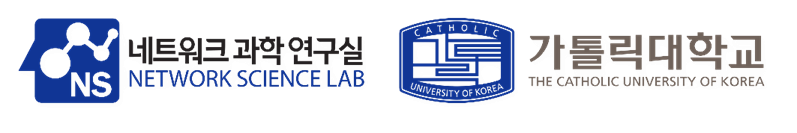

# Practice 6: Link Prediction in Graphs 🕸️

This notebook demonstrates various **Link Prediction** algorithms. Link prediction attempts to estimate the likelihood of the existence of a link between two nodes, based on observed links and the attributes of nodes.

You can find out more at [Proximity-based Methods for Link Prediction](https://cran.r-project.org/web/packages/linkprediction/vignettes/proxfun.html)

---
## 📑 Table of Contents
1. [Import Necessary Libraries](#1.-import-necessary-libraries-📦)
2. [Common Neighbors](#2.-common-neighbors-%)
3. [Jaccard’s Coefficient](#3.-jaccard’s-coefficient-%)
4. [Adamic-Adar Index](#4.-adamic-adar-index-%)
5. [Preferential Attachment](#5.-preferential-attachment-%)
6. [Salton Index (Cosine Similarity)](#6.-salton-index-(cosine-similarity)-%)
7. [Sorensen Index](#7.-sorensen-index-%)
8. [Hub Promoted Index (HPI)](#8.-hub-promoted-index-(hpi)-%)
9. [Hub Depressed Index (HDI)](#9.-hub-depressed-index-(hdi)-%)
10. [Path-Based Katz Index](#10.-path-based-katz-index-%)
11. [Path-Based Hitting Time](#11.-path-based-hitting-time-%)
12. [SimRank Similarity](#12.-simrank-similarity-%)
13. [Large-Scale Graph Processing](#13.-large-scale-graph-processing-%)

---
## 1. Import Necessary Libraries 📦

In [1]:
import networkx as nx
import numpy as np
import pandas as pd

---
## 2. Common Neighbors 🤝

The **Common Neighbors** metric counts the number of neighbors that two nodes share. A higher count suggests a higher probability that the two nodes will connect.

Let $N(u)$ be the set of neighbors of node $u$, and $N(v)$ be the set of neighbors of node $v$. 
The Common Neighbors score is defined as:
$$ CN(u, v) = |N(u) \cap N(v)| $$

Common neighbors of [3, 6, 9]: [1, 10]


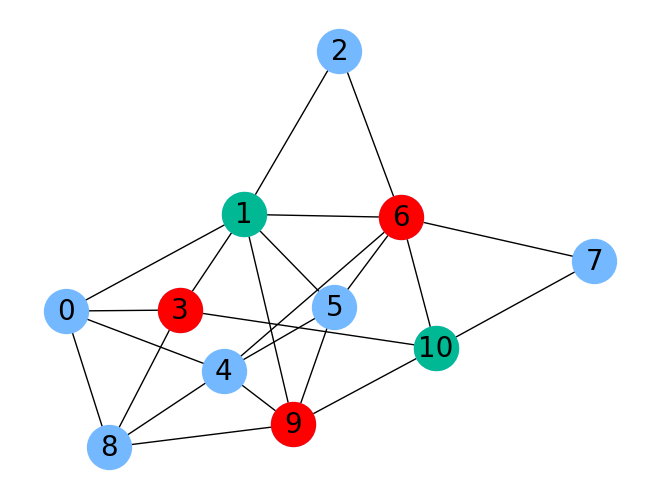

In [2]:
from itertools import combinations

# Get common values in two lists
def common_values(a, b):
    return [value for value in a if value in b]

# Get list of common neighbors
def get_common_neighbors(G, node_list):
    cn_list = G.nodes
    node_pairs = list(combinations(node_list, 2))
    
    for pair in node_pairs:
        cn_in_node_pair = sorted(nx.common_neighbors(G, pair[0], pair[1]))
        cn_list = common_values(cn_list, cn_in_node_pair)

    return cn_list

# Define graph
G = nx.read_edgelist('./data/edge_list.txt')

# Relabel nodes from string to int
mapping = {f'{i}': i for i in range(11)}
G = nx.relabel_nodes(G, mapping)

# Choose list of nodes to get common neighbors
target_nodes = [3, 6, 9]

# Get list of common neighbors
cn_list = get_common_neighbors(G, target_nodes)

print(f"Common neighbors of {target_nodes}: {cn_list}")

pos = nx.spring_layout(G)
nx.draw(G, pos,
        node_size=1000,
        node_color='#74b9ff',
        with_labels=True,
        font_size = 20)

# Mark common neighbors as green color
nx.draw_networkx_nodes(G, pos, node_size=1000, nodelist=cn_list, node_color='#00b894')

# Mark target nodes as red color
nx.draw_networkx_nodes(G, pos, node_size=1000, nodelist=target_nodes, node_color='r')

---
## 3. Jaccard’s Coefficient 📊

**Jaccard’s Coefficient** normalizes the Common Neighbors score by dividing it by the total number of distinct neighbors that both nodes have. This ensures that nodes with exceptionally high degrees don't dominate the prediction.

The Jaccard coefficient is defined as:
$$ Jaccard(u, v) = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|} $$

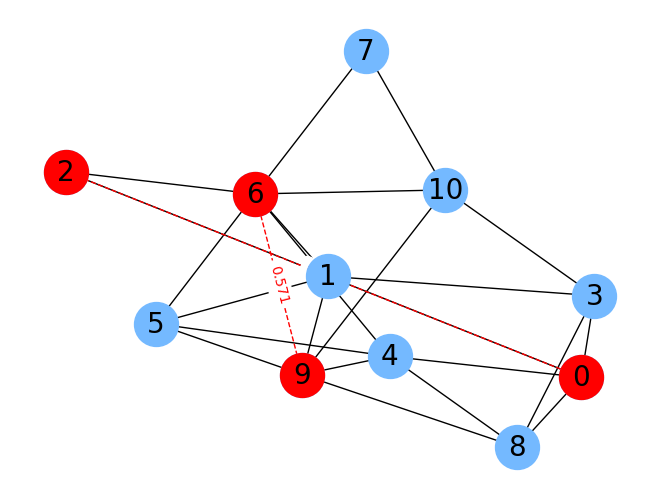

In [3]:
# Draw graph with coefficient edges
def draw_coefficient_edges(G, preds):
    edge_labels = {}
    target_list = []

    for u, v, p in preds:
        edge_labels[(u, v)] = f"{p:.3f}"
        target_list.append(u)
        target_list.append(v)
        
    pos = nx.spring_layout(G)

    nx.draw(G, pos, 
            node_size=1000,
            node_color='#74b9ff',
            with_labels=True,
            font_size = 20)
    # Mark target nodes as green color
    nx.draw_networkx_nodes(G, pos, 
                           nodelist=target_list,
                           node_size=1000,
                           node_color='r')
    nx.draw_networkx_edges(G, pos, edgelist=node_list, style='dashed', edge_color='r')

    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_color='red'
    )

# Calculate Jaccard’s coefficient of node pairs in a list of nodes
node_list = [(6, 9), (0, 2)]
preds = nx.jaccard_coefficient(G, node_list)
draw_coefficient_edges(G, preds)

---
## 4. Adamic-Adar Index 📈

The **Adamic-Adar (AA) Index** heavily weights rare common neighbors. If two nodes share a neighbor that is highly connected everywhere, it's not very special. If they share a neighbor with very few connections, it's a stronger predictor of a link!

The AA Index is defined as:
$$ AA(u, v) = \sum_{z \in N(u) \cap N(v)} \frac{1}{\log(|N(z)|)} $$

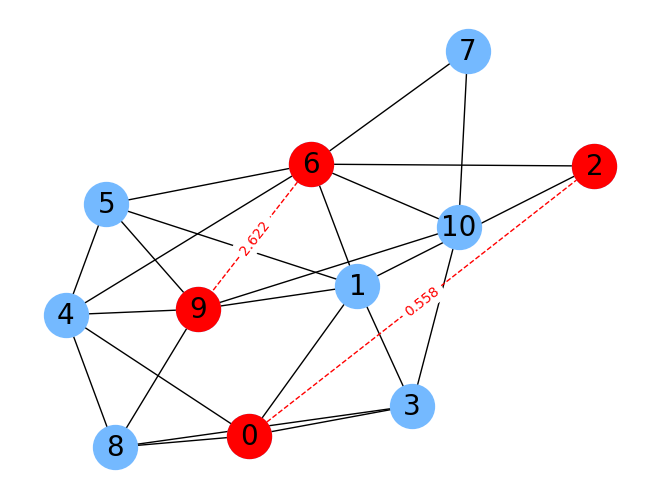

In [4]:
# Calculate Adamic-Adar index of node pairs in a list of nodes
def calculate_adamic_adar_index(G, node_list):
    # Check if nodes exist in the graph
    for node_pair in node_list:
        if not all(node in G for node in node_pair):
            print(f"Node pair {node_pair} does not exist in the graph.")
            return
    return list(nx.adamic_adar_index(G, node_list))

# Define node pairs
node_list = [(6, 9), (0, 2)]

# Calculate Adamic-Adar index
preds = calculate_adamic_adar_index(G, node_list)

# Draw graph with coefficient edges
if preds:
    draw_coefficient_edges(G, preds)

---
## 5. Preferential Attachment (PA) ⭐

**Preferential attachment** suggests that nodes with higher degrees are more likely to get new edges. So, the likelihood of a link between two nodes is heavily influenced by the degree of those nodes.

The PA index is calculated by multiplying the degrees of the two nodes:
$$ PA(u, v) = |N(u)| \times |N(v)| $$

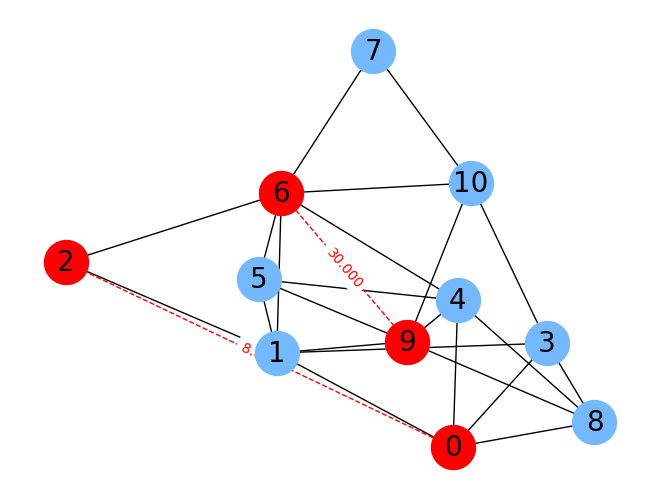

In [5]:
# Calculate Preferential Attachment of node pairs in a list of nodes
def calculate_preferential_attachment(G, node_list):
    # Check if nodes exist in the graph
    for node_pair in node_list:
        if not all(node in G for node in node_pair):
            print(f"Node pair {node_pair} does not exist in the graph.")
            return
    return list(nx.preferential_attachment(G, node_list))

# Define node pairs
node_list = [(6, 9), (0, 2)]

# Calculate Preferential Attachment
preds = calculate_preferential_attachment(G, node_list)

# Draw graph with coefficient edges
if preds:
    draw_coefficient_edges(G, preds)

---
## 6. Salton Index (Cosine Similarity) 📐

The **Salton Index** (also called **Cosine Similarity** in unweighted graphs) measures how similar two nodes are based on how much their neighbor sets overlap, while normalizing by their degrees.

It can be interpreted as the cosine of the angle between the binary adjacency vectors of nodes \(u\) and \(v\):
- value close to **1** → very similar neighborhoods  
- value close to **0** → little or no neighborhood overlap

The Salton index is defined as:
$$
Salton(u,v) = \frac{|N(u)\cap N(v)|}{\sqrt{|N(u)|\times|N(v)|}}
$$

where:
- $N(u)$: set of neighbors of node $u$
- $N(v)$: set of neighbors of node $v$
- $|N(u)\cap N(v)|$: number of common neighbors between $u$ and $v$
- $|N(u)|,\ |N(v)|$: degrees (number of neighbors) of $u$ and $v$

This normalization helps prevent high-degree nodes from dominating the score, making it more balanced than plain Common Neighbors.  
For isolated nodes (degree 0), the score is undefined and typically handled as 0 or skipped.

**Source:** [Salton Index (Cosine Similarity)][salton]

[salton]: https://github.com/SubhojitGhimire/Salton-Index-Cosine-Similarity

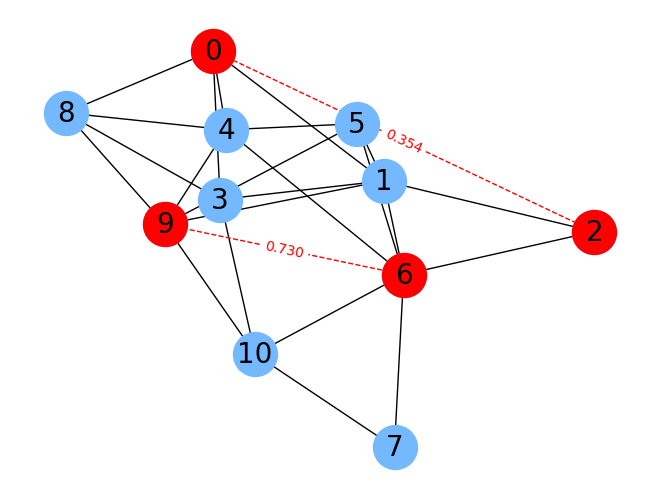

In [6]:
import math

def salton_index(G, u, v):
    # Check if nodes exist in the graph and their degree is not zero
    if u not in G or v not in G or G.degree(u) == 0 or G.degree(v) == 0:
        print(f"Node pair ({u}, {v}) does not exist in the graph or their degree is zero.")
        return
    return len(sorted(nx.common_neighbors(G, u, v))) / math.sqrt(G.degree(u) * G.degree(v))

# Calculate Salton index of a list of node pairs
def calculate_salton_index(G, node_list):
    return ((source, target, salton_index(G, source, target)) for source, target in node_list if salton_index(G, source, target) is not None)

node_list =  [(6, 9), (0, 2)]
preds = list(calculate_salton_index(G, node_list))

# Draw graph with coefficient edges
if preds:
    draw_coefficient_edges(G, preds)

---
## 7. Sørensen Index ⚖️

The **Sørensen Index** (also called **Sørensen-Dice coefficient**) is a statistical tool used to gauge the similarity between two sets of data. It is related to the Jaccard index but weights the intersection twice, making it particularly useful for comparing nodes with small neighborhoods.

### Mathematical Definition

The Sørensen-Dice Index is defined as:
$$SD = \frac{2 \times C}{A + B}$$

Where:
- $SD$ is the Sørensen-Dice Index value
- $C$ is the number of species (or neighbors) common to both samples (nodes)
- $A$ is the total number of species (or neighbors) in sample A
- $B$ is the total number of species (or neighbors) in sample B

### Key Properties

- **Range**: Values between 0 and 1
    - Value **close to 1** → nodes have very similar neighborhoods
    - Value **close to 0** → nodes have little to no common neighbors

### Intuition

Think of it this way: if two nodes $A$ and $B$ together have 10 unique neighbors (after removing duplicates), and they share 4 of them, then:
- **Jaccard** = 4/10 = 0.4
- **Sørensen** = 2×4/(5+5) = 8/10 = 0.8

Sørensen gives more weight to the overlap, making it more lenient when comparing nodes.

### Example
In a social network:
- User A has 5 friends: {B, C, D, E, F} -> $A = 5$
- User G has 3 friends: {D, E, H} -> $B = 3$
- Common friends: {D, E} → $C = 2$ friends in common

$$SD = \frac{2 \times 2}{5 + 3} = \frac{4}{8} = 0.5$$

This suggests moderate likelihood that A and G will become friends.

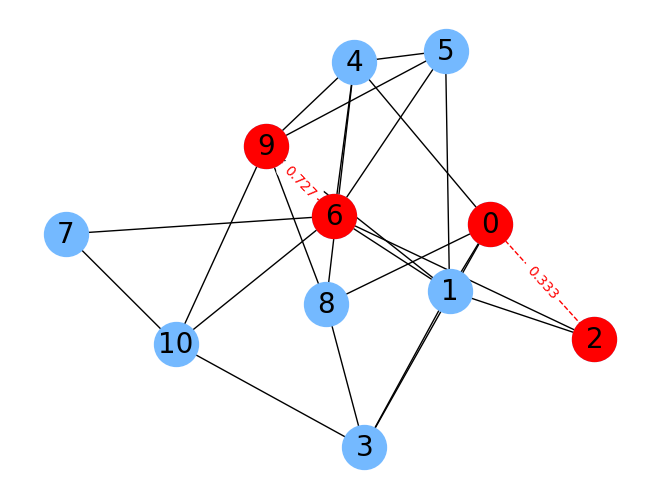

In [7]:
# Calculate Sorensen index two nodes
def sorensen_index(G, u, v):
    # Check if nodes exist in the graph and their degree is not zero
    if u not in G or v not in G or G.degree(u) == 0 or G.degree(v) == 0:
        print(f"Node pair ({u}, {v}) does not exist in the graph or their degree is zero.")
        return
    return 2 * len(sorted(nx.common_neighbors(G, u, v))) / (G.degree(u) + G.degree(v))

# Calculate Sorensen index of a list of node pairs
def calculate_sorensen_index(G, node_list):
    return ((source, target, sorensen_index(G, source, target)) for source, target in node_list if sorensen_index(G, source, target) is not None)

node_list =  [(6, 9), (0, 2)]
preds = list(calculate_sorensen_index(G, node_list))

# Draw graph with coefficient edges
if preds:
    draw_coefficient_edges(G, preds)

---
## 8. Hub Promoted Index (HPI) ⬆️

The **Hub Promoted Index (HPI)** measures the topological overlap of two nodes and assigns a higher score to links involving hubs (highly connected nodes). It prevents high-degree nodes from being penalized.

The HPI is defined as:
$$ HPI(u,v) = \frac{|N(u) \cap N(v)|}{\min(|N(u)|, |N(v)|)} $$

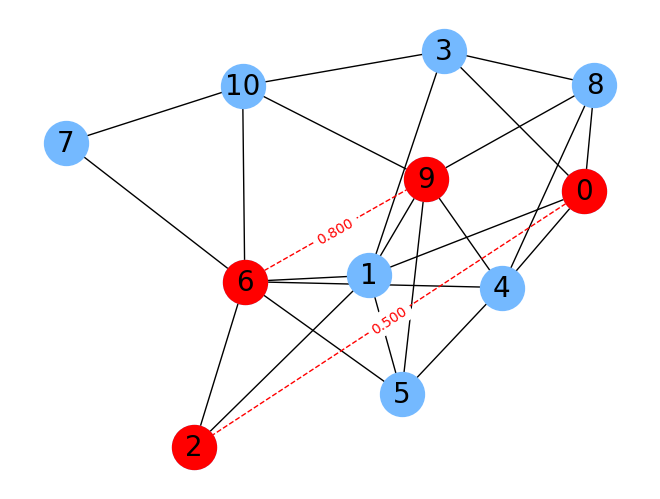

In [8]:
# Calculate Hub Promoted index two nodes
def hub_promoted_index(G, u, v):
    # Check if nodes exist in the graph and their degree is not zero
    if u not in G or v not in G or G.degree(u) == 0 or G.degree(v) == 0:
        print(f"Node pair ({u}, {v}) does not exist in the graph or their degree is zero.")
        return
    return len(sorted(nx.common_neighbors(G, u, v))) / min(G.degree(u), G.degree(v))

# Function to calculate Hub Promoted index of a list of node pairs
def calculate_hub_promoted_index(G, node_list):
    return ((source, target, hub_promoted_index(G, source, target)) for source, target in node_list if hub_promoted_index(G, source, target) is not None)

node_list =  [(6, 9), (0, 2)]
preds = list(calculate_hub_promoted_index(G, node_list))

# Draw graph with coefficient edges
if preds:
    draw_coefficient_edges(G, preds)

---
## 9. Hub Depressed Index (HDI) ⬇️

In contrast to the Hub Promoted Index, the **Hub Depressed Index (HDI)** penalizes connections to hubs. It assigns a higher score to adjacent nodes with smaller degree overlaps.

The HDI is defined as:
$$ HDI(u,v) = \frac{|N(u) \cap N(v)|}{\max(|N(u)|, |N(v)|)} $$

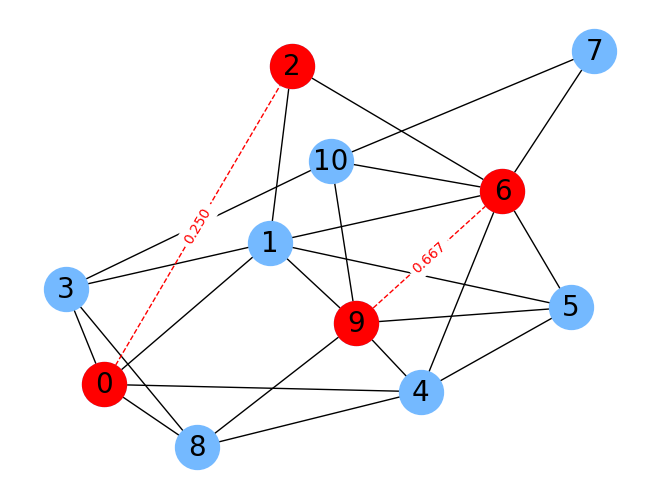

In [9]:
# Calculate Hub Depressed index two nodes
def hub_depressed_index(G, u, v):
    # Check if nodes exist in the graph and their degree is not zero
    if u not in G or v not in G or G.degree(u) == 0 or G.degree(v) == 0:
        print(f"Node pair ({u}, {v}) does not exist in the graph or their degree is zero.")
        return
    return len(sorted(nx.common_neighbors(G, u, v))) / max(G.degree(u), G.degree(v))

# Calculate Hub Depressed index of a list of node pairs
def calculate_hub_depressed_index(G, node_list):
    return ((source, target, hub_depressed_index(G, source, target)) for source, target in node_list if hub_depressed_index(G, source, target) is not None)

node_list =  [(6, 9), (0, 2)]
preds = list(calculate_hub_depressed_index(G, node_list))

# Draw graph with coefficient edges
if preds:
    draw_coefficient_edges(G, preds)

---
## 10. Path-Based Katz Index 🛤️

The **Katz Index** measures the relative degree of influence by considering all possible walks between a pair of nodes, but penalizing longer walks via a damping factor $\beta$. A higher Katz Score between a pair implies a tighter relation.

The Katz similarity matrix is defined as:
$$ S_{Katz} = (I - \beta A)^{-1} - I $$
Where $I$ is the identity matrix, $A$ is the adjacency matrix, and $\beta$ must be smaller than the inverse of the largest eigenvalue of the Laplacian matrix.

Largest eigenvalue: 1.6278814533249757


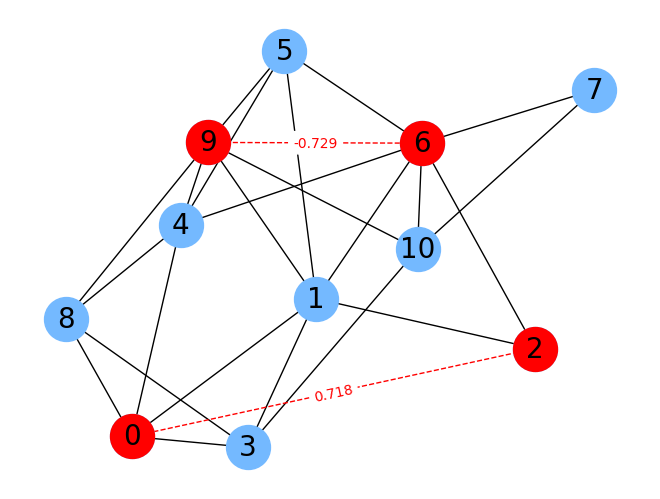

In [10]:
import networkx as nx
import numpy as np
from numpy.linalg import inv

# Calculate highest eigenvector
L = nx.normalized_laplacian_matrix(G)
e = np.linalg.eigvals(L.toarray())
node_list = [(6, 9), (0, 2)]

print("Largest eigenvalue:", max(e))
beta = 1/max(e)
I = np.identity(len(G.nodes)) #create identity matrix

# Katz score
katz_matrix = np.linalg.inv(I - nx.to_numpy_array(G)*beta) - I

# Get Katz score for node pairs
katz_score = []
for node_pair in node_list:
    katz_score.append((node_pair[0], node_pair[1], katz_matrix[node_pair[0], node_pair[1]]))

# Draw graph with coefficient edges
draw_coefficient_edges(G, katz_score)




---
## 11. Path-Based Hitting Time ⏱️

**Hitting time**, or Commute Time, involves random walks. It represents the expected number of steps required for a random walker starting at node $u$ to reach node $v$. A smaller hitting time points to a higher probability of a link formed there.

The Hitting Time expected value depends on the Laplacian matrix and can be written formally as:
$$ H_{uv} \propto \text{Commute Distance} $$

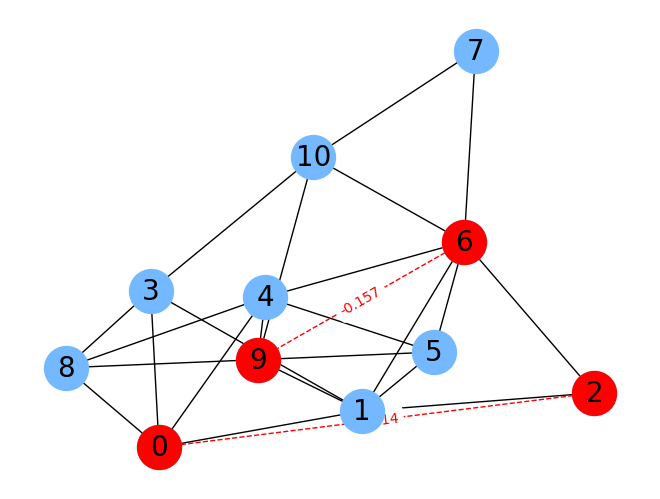

In [11]:
def calculate_hitting_time(adj_matrix, source, target):
    n = adj_matrix.shape[0]
    I = np.eye(n)
    N = np.linalg.inv(I - adj_matrix)
    h = np.zeros(n)
    
    for j in range(n):
        if j != source:
            h[j] = N[j, j] - N[source, j]
    
    h /= n - 1
    
    return h[target]

node_list = [(6, 9), (0, 2)]
adj_matrix = nx.to_numpy_array(G)

hitting_time = [(node_pair[0], node_pair[1], calculate_hitting_time(adj_matrix, node_pair[0], node_pair[1])) for node_pair in node_list]

# Draw graph with coefficient edges
draw_coefficient_edges(G, hitting_time)


---
## 12. SimRank Similarity 🔄

**SimRank** measures the structural context similarity of two nodes by considering their incoming links iteratively. Simply put: *"Two nodes are similar if they are referenced by similar nodes"*.

The SimRank score is defined through a recursive equation:
$$ s(u,v) = C \cdot \frac{\sum_{x \in N(u)} \sum_{y \in N(v)} s(x,y)}{|N(u)| \times |N(v)|} $$
Where $C$ is a constant decay factor.

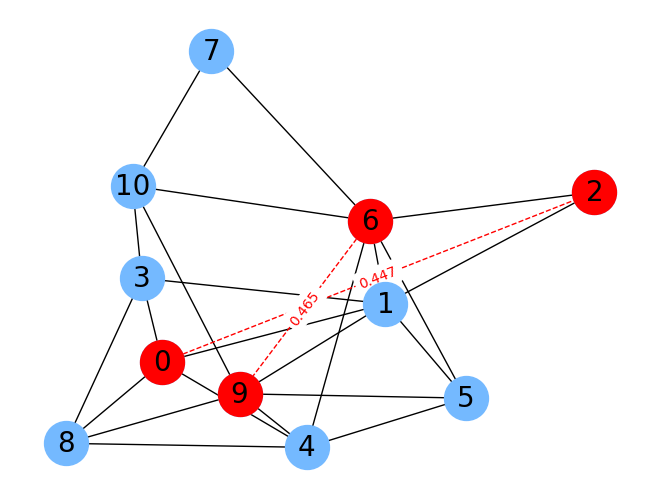

In [12]:
# Calculate SimRank similarity of two nodes
def simrank_similarity(G, u, v):
    # Check if nodes exist in the graph
    if u not in G or v not in G:
        print(f"Node pair ({u}, {v}) does not exist in the graph.")
        return
    return nx.simrank_similarity(G, source=u, target=v)

# Calculate SimRank similarity of a list of node pairs
def calculate_simrank_similarity(G, node_list):
    return ((source, target, simrank_similarity(G, source, target)) for source, target in node_list if simrank_similarity(G, source, target) is not None)

node_list =  [(6, 9), (0, 2)]
preds = list(calculate_simrank_similarity(G, node_list))

# Draw graph with coefficient edges
if preds:
    draw_coefficient_edges(G, preds)

---
## 13. Large-Scale Graph Processing 🌍

Link prediction algorithms have a very high time spatial complexity because we have to process thousands of pair combinations. We shift towards a large-scale graph scenario.

In [13]:
import matplotlib.pyplot as plt
import networkx as nx

# Largest connected component
def get_largest_component(G):
    components = nx.connected_components(G)
    largest_component = max(components, key=len)
    largest_subgraph = G.subgraph(largest_component)
    
    return largest_subgraph

# Function to calculate betweenness centrality and community structure
def calculate_centrality_and_community(largest_component):
    # Calculate betweenness centrality
    centrality = nx.betweenness_centrality(largest_component, k=10, endpoints=True)

    # Compute community structure
    lpc = nx.community.label_propagation_communities(largest_component)
    community_index = {n: i for i, com in enumerate(lpc) for n in com}

    return centrality, community_index

def draw_graph(G, largest_component, pos, centrality, community_index):
    # Draw graph using matplotlib
    fig, ax = plt.subplots(figsize=(20, 15))
    node_color = [community_index[n] for n in largest_component]
    node_size = [v * 20000 for v in centrality.values()]
    nx.draw_networkx(
        largest_component,
        pos=pos,
        with_labels=True,
        node_color=node_color,
        node_size=node_size,
        edge_color="gainsboro",
        alpha=0.4,
    )

    # Title/legend
    font = {"color": "blue", "fontweight": "bold", "fontsize": 20}
    ax.set_title("Biological Network", font)

# Read graph data from edgelist
G = nx.read_weighted_edgelist("data/CE-GT.txt")



SimRank similarity: 
(B0523.3, Y37D8A.23) -> 0.01136158
(F11C3.3, K12F2.1) -> 0.28301630
(C52B9.9, C44H4.3) -> 0.01235652


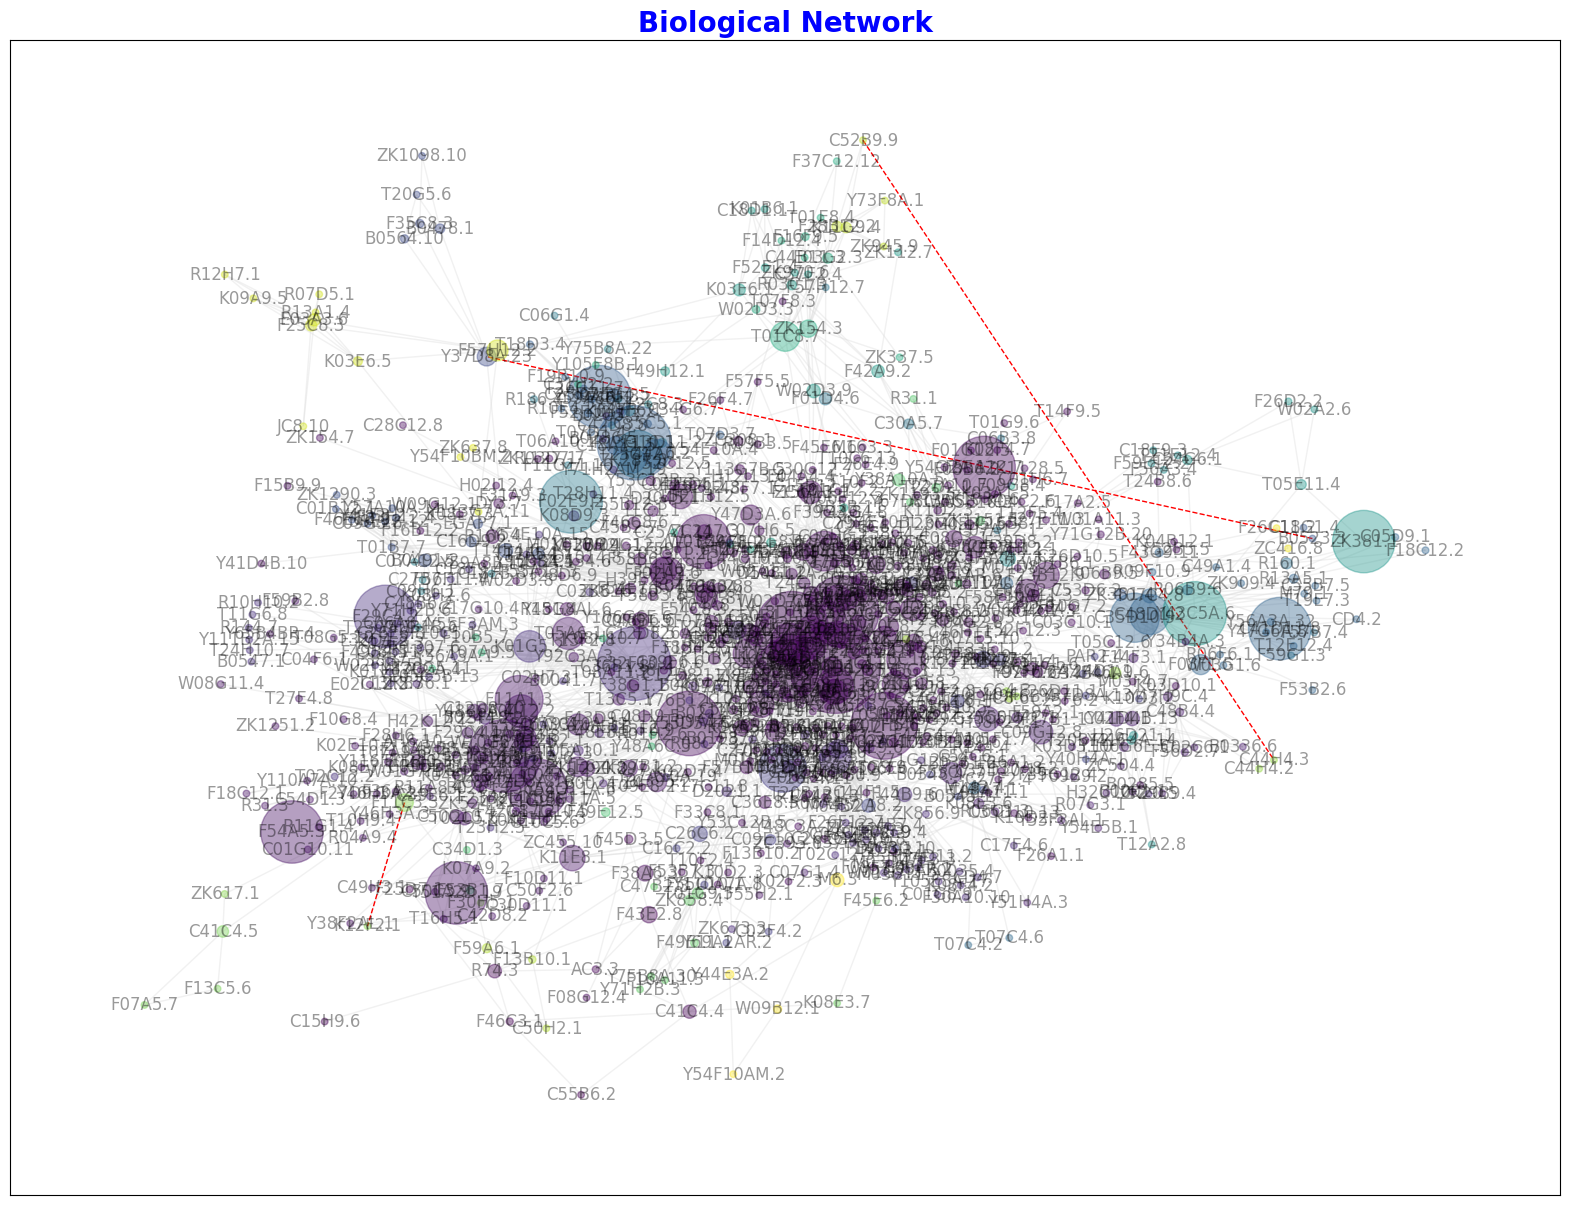

In [14]:
# Spring layout
largest_component = get_largest_component(G)
pos = nx.spring_layout(largest_component, k=0.15)

centrality, community_index = calculate_centrality_and_community(largest_component)
draw_graph(G, largest_component, pos, centrality, community_index)

node_list =  [('B0523.3', 'Y37D8A.23'), ('F11C3.3', 'K12F2.1'), ('C52B9.9', 'C44H4.3')]
preds = calculate_simrank_similarity(G, node_list)

print("SimRank similarity: ")
for u, v, p in preds:
    print(f"({u}, {v}) -> {p:.8f}")

target_list = [node for edge in node_list for node in edge]

# Mark edges
nx.draw_networkx_edges(G, pos, edgelist=node_list, style='dashed', edge_color='r')

In [15]:
# Common neighbors
for node_pair in node_list:
    cn = sorted(nx.common_neighbors(G, node_pair[0], node_pair[1]))
    print(f"Common neighbors of {node_pair}: {cn}")


Common neighbors of ('B0523.3', 'Y37D8A.23'): []
Common neighbors of ('F11C3.3', 'K12F2.1'): ['F30H5.1']
Common neighbors of ('C52B9.9', 'C44H4.3'): []


In [16]:
# Jaccard Coefficient
def calculate_jaccard_coefficient(G, node_list):
    return list(nx.jaccard_coefficient(G, node_list))

for u, v in node_list:
    jaccard_coefficient = calculate_jaccard_coefficient(largest_component, [(u, v)])
    print(f"Jaccard Coefficient between {u} and {v}: {jaccard_coefficient}")

Jaccard Coefficient between B0523.3 and Y37D8A.23: [('B0523.3', 'Y37D8A.23', 0.0)]
Jaccard Coefficient between F11C3.3 and K12F2.1: [('F11C3.3', 'K12F2.1', 0.14285714285714285)]
Jaccard Coefficient between C52B9.9 and C44H4.3: [('C52B9.9', 'C44H4.3', 0.0)]


In [17]:
# Adamic-Adar
for u, v in node_list:
    adamic_adar = calculate_adamic_adar_index(largest_component, [(u, v)])
    print(f"Adamic-Adar Index between {u} and {v}: {adamic_adar}")

Adamic-Adar Index between B0523.3 and Y37D8A.23: [('B0523.3', 'Y37D8A.23', 0)]
Adamic-Adar Index between F11C3.3 and K12F2.1: [('F11C3.3', 'K12F2.1', 1.4426950408889634)]
Adamic-Adar Index between C52B9.9 and C44H4.3: [('C52B9.9', 'C44H4.3', 0)]


In [18]:
# Preferential Attachment
for u, v in node_list:
    preferential_attachment = calculate_preferential_attachment(largest_component, [(u, v)])
    print(f"Preferential Attachment between {u} and {v}: {preferential_attachment}")

Preferential Attachment between B0523.3 and Y37D8A.23: [('B0523.3', 'Y37D8A.23', 5)]
Preferential Attachment between F11C3.3 and K12F2.1: [('F11C3.3', 'K12F2.1', 12)]
Preferential Attachment between C52B9.9 and C44H4.3: [('C52B9.9', 'C44H4.3', 4)]


In [19]:
# Salton index
def salton_index2(G, u, v):
    # Check if nodes exist in the graph and their degree is not zero
    if u not in G or v not in G or G.degree(u) == 0 or G.degree(v) == 0:
        print(f"Node pair ({u}, {v}) does not exist in the graph or their degree is zero.")
        return
    return len(sorted(nx.common_neighbors(G, u, v))) / math.sqrt(G.degree(u) * G.degree(v))

for u, v in node_list:
    salton_index = salton_index2(largest_component, u, v)
    print(f"Salton Index between {u} and {v}: {salton_index}")

Salton Index between B0523.3 and Y37D8A.23: 0.0
Salton Index between F11C3.3 and K12F2.1: 0.2886751345948129
Salton Index between C52B9.9 and C44H4.3: 0.0


In [20]:
# Sorensen index
def sorensen_index2(G, u, v):
    # Check if nodes exist in the graph and their degree is not zero
    if u not in G or v not in G or G.degree(u) == 0 or G.degree(v) == 0:
        print(f"Node pair ({u}, {v}) does not exist in the graph or their degree is zero.")
        return
    return 2 * len(sorted(nx.common_neighbors(G, u, v))) / (G.degree(u) + G.degree(v))

for u, v in node_list:
    sorensen_index = sorensen_index2(largest_component, u, v)
    print(f"Sorensen Index between {u} and {v}: {sorensen_index}")

Sorensen Index between B0523.3 and Y37D8A.23: 0.0
Sorensen Index between F11C3.3 and K12F2.1: 0.25
Sorensen Index between C52B9.9 and C44H4.3: 0.0


In [21]:
# Hub Promoted index
def hub_promoted_index2(G, u, v):
    # Check if nodes exist in the graph and their degree is not zero
    if u not in G or v not in G or G.degree(u) == 0 or G.degree(v) == 0:
        print(f"Node pair ({u}, {v}) does not exist in the graph or their degree is zero.")
        return
    return len(sorted(nx.common_neighbors(G, u, v))) / min(G.degree(u), G.degree(v))

for u, v in node_list:
    hub_promoted_index = hub_promoted_index2(largest_component, u, v)
    print(f"Hub Promoted Index between {u} and {v}: {hub_promoted_index}")

Hub Promoted Index between B0523.3 and Y37D8A.23: 0.0
Hub Promoted Index between F11C3.3 and K12F2.1: 0.5
Hub Promoted Index between C52B9.9 and C44H4.3: 0.0


In [22]:
# Hub Depressed index
def hub_depressed_index2(G, u, v):
    # Check if nodes exist in the graph and their degree is not zero
    if u not in G or v not in G or G.degree(u) == 0 or G.degree(v) == 0:
        print(f"Node pair ({u}, {v}) does not exist in the graph or their degree is zero.")
        return
    return len(sorted(nx.common_neighbors(G, u, v))) / max(G.degree(u), G.degree(v))

for u, v in node_list:
    hub_depressed_index = hub_depressed_index2(largest_component, u, v)
    print(f"Hub Depressed Index between {u} and {v}: {hub_depressed_index}")


Hub Depressed Index between B0523.3 and Y37D8A.23: 0.0
Hub Depressed Index between F11C3.3 and K12F2.1: 0.16666666666666666
Hub Depressed Index between C52B9.9 and C44H4.3: 0.0
